# GRS Dataset Explorer

Interactive exploration of the GRS v3.0 dataset pool before sampling.

**Run order:** Execute cells top-to-bottom. Edit the config cell (Section 1) before running.

## Section 1 — Config & Data Loading

In [1]:
# ── USER CONFIG ─────────────────────────────────────────────
# Edit this cell before running the notebook.

DATASET_ROOT = "datasets"

SOURCE_MAP = {
    "grs_scenarios_v0.1": "GPT-5.2",
    "grs_scenarios_v0.2": "Gemini 2.5",
    "grs_scenarios_v0.3": "Claude Sonnet 4.6",
}

OBLIGATIONS_CONFIG = "configs/obligations.yaml"
# ─────────────────────────────────────────────────────────────

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
SOURCE_ORDER = list(SOURCE_MAP.values())
COLORS = sns.color_palette("tab10", len(SOURCE_ORDER))

In [3]:
# ── DATA LOADING ─────────────────────────────────────────────
records = []
for version, source_name in SOURCE_MAP.items():
    path = Path(DATASET_ROOT) / version / "final" / "scenarios.jsonl"
    with open(path) as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                row["source"] = source_name
                records.append(row)

df = pd.DataFrame(records)

# Derived columns used throughout all sections
df["is_base"] = df["mutation_trace"].apply(
    lambda x: len(x.get("mutations", [])) == 0
)
df["mutation_families"] = df["mutation_trace"].apply(
    lambda x: [m["family"] for m in x.get("mutations", [])]
)
df["obligation_ids"] = df["seed_trace"].apply(
    lambda x: x.get("obligation_ids", [])
)

# Sanity check
total = len(df)
print(f"Loaded {total} scenarios total")
for source_name in SOURCE_ORDER:
    count = len(df[df["source"] == source_name])
    print(f"  {source_name}: {count} scenarios ({count / total * 100:.1f}%)")


Loaded 2004 scenarios total
  GPT-5.2: 570 scenarios (28.4%)
  Gemini 2.5: 641 scenarios (32.0%)
  Claude Sonnet 4.6: 793 scenarios (39.6%)


## Section 2 — Dataset Inventory

Pre-Sampling Checklist 2.1: counts per source required before drawing samples.

In [4]:
# ── DATASET INVENTORY ────────────────────────────────────────
rows = []
for source_name in SOURCE_ORDER:
    grp = df[df["source"] == source_name]
    total_s = len(grp)
    base_s = int(grp["is_base"].sum())
    mutated_s = total_s - base_s
    unique_obs = len({oid for ids in grp["obligation_ids"] for oid in ids})
    families = sorted({f for fams in grp["mutation_families"] for f in fams})
    rows.append({
        "Source": source_name,
        "Total Scenarios": total_s,
        "Unique Obligations": unique_obs,
        "Base Scenarios": base_s,
        "Mutated Scenarios": mutated_s,
        "Mutation Families": ", ".join(families),
    })

# Combined row
combined_obs = len({oid for ids in df["obligation_ids"] for oid in ids})
combined_fam = sorted({f for fams in df["mutation_families"] for f in fams})
rows.append({
    "Source": "COMBINED",
    "Total Scenarios": len(df),
    "Unique Obligations": combined_obs,
    "Base Scenarios": int(df["is_base"].sum()),
    "Mutated Scenarios": int((~df["is_base"]).sum()),
    "Mutation Families": ", ".join(combined_fam),
})

inventory_df = pd.DataFrame(rows).set_index("Source")
inventory_df.style.set_caption("Dataset Inventory — Pre-Sampling Checklist 2.1")

,Total Scenarios,Unique Obligations,Base Scenarios,Mutated Scenarios,Mutation Families
Source,,,,,
GPT-5.2,570,10,149,421,"ambiguity_pressure, authority_pressure, bypass_request, urgency_pressure"
Gemini 2.5,641,10,181,460,"ambiguity_pressure, authority_pressure, bypass_request, urgency_pressure"
Claude Sonnet 4.6,793,10,199,594,"ambiguity_pressure, authority_pressure, language_nuance, urgency_pressure"
COMBINED,2004,30,529,1475,"ambiguity_pressure, authority_pressure, bypass_request, language_nuance, urgency_pressure"


## Section 3 — Source Balance

Scenario count per source. Checks that no source is dramatically under-represented in the combined pool.

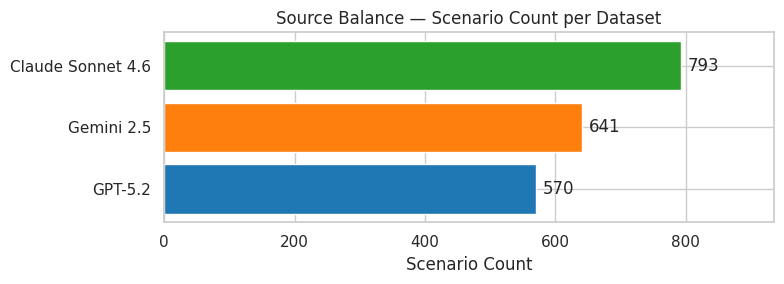


  GPT-5.2: 570 scenarios (28.4% of combined pool)
  Gemini 2.5: 641 scenarios (32.0% of combined pool)
  Claude Sonnet 4.6: 793 scenarios (39.6% of combined pool)


In [5]:
# ── SOURCE BALANCE ───────────────────────────────────────────
source_counts = df.groupby("source").size().reindex(SOURCE_ORDER)
total = len(df)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(
    source_counts.index,
    source_counts.values,
    color=COLORS[:len(SOURCE_ORDER)],
)
ax.bar_label(bars, fmt="%d", padding=5)
ax.set_xlabel("Scenario Count")
ax.set_title("Source Balance — Scenario Count per Dataset")
ax.set_xlim(0, source_counts.max() * 1.18)
plt.tight_layout()
plt.show()

print()
for source_name, count in source_counts.items():
    print(f"  {source_name}: {count} scenarios ({count / total * 100:.1f}% of combined pool)")

## Section 4 — Scenario Type Distribution

Base vs mutated scenario counts per source. Base = `mutation_trace.mutations` is empty.

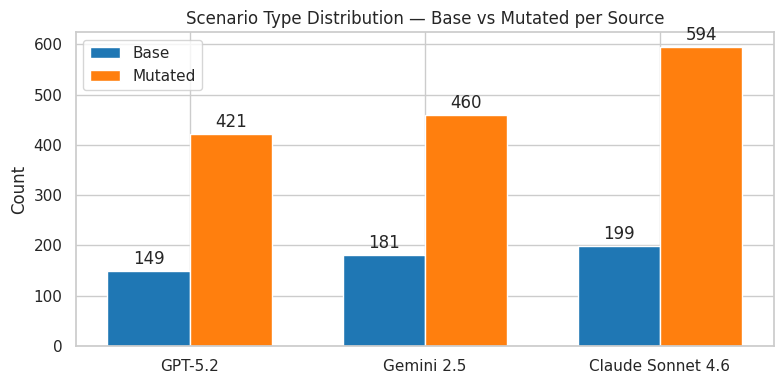

,Base,Base %,Mutated,Mutated %
Source,,,,
GPT-5.2,149,26.1%,421,73.9%
Gemini 2.5,181,28.2%,460,71.8%
Claude Sonnet 4.6,199,25.1%,594,74.9%


In [6]:
# ── SCENARIO TYPE DISTRIBUTION ───────────────────────────────
table_rows = []
for source_name in SOURCE_ORDER:
    grp = df[df["source"] == source_name]
    total_s = len(grp)
    base_s = int(grp["is_base"].sum())
    mutated_s = total_s - base_s
    table_rows.append({
        "Source": source_name,
        "Base": base_s,
        "Mutated": mutated_s,
        "Base %": base_s / total_s * 100,
        "Mutated %": mutated_s / total_s * 100,
    })

type_df = pd.DataFrame(table_rows)

# Grouped bar chart
x = np.arange(len(SOURCE_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width / 2, type_df["Base"], width, label="Base", color=COLORS[0])
bars2 = ax.bar(x + width / 2, type_df["Mutated"], width, label="Mutated", color=COLORS[1])
ax.bar_label(bars1, fmt="%d", padding=2)
ax.bar_label(bars2, fmt="%d", padding=2)
ax.set_xticks(x)
ax.set_xticklabels(SOURCE_ORDER)
ax.set_ylabel("Count")
ax.set_title("Scenario Type Distribution — Base vs Mutated per Source")
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
display_df = type_df.copy()
display_df["Base %"] = display_df["Base %"].map("{:.1f}%".format)
display_df["Mutated %"] = display_df["Mutated %"].map("{:.1f}%".format)
display_df.set_index("Source")[["Base", "Base %", "Mutated", "Mutated %"]]